In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install -U "numpy==2.0.2" "protobuf>=5.26.1,<6" opencv-python opencv-python-headless mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.2 MB/s eta 0:00:00


In [ ]:
import numpy as np, tensorflow as tf
import mediapipe as mp
import cv2

print("numpy:", np.__version__)
print("tf:", tf.__version__)
print("mediapipe:", mp.__version__)
print("cv2:", cv2.__version__)

numpy: 2.0.2
tf: 2.19.0
mediapipe: 0.10.33
cv2: 4.13.0


In [ ]:
import os
import numpy as np
import cv2
from glob import glob
from google.colab import drive
from tqdm import tqdm

import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision

drive.mount("/content/drive")

PATH_PD = "/content/drive/MyDrive/face_PD_Healthy/PD"
PATH_HEALTHY = "/content/drive/MyDrive/face_PD_Healthy/Healthy"
OUT_NPZ = "/content/face_local_features_asym_plus.npz"

MODEL_PATH = "/content/face_landmarker.task"
if not os.path.exists(MODEL_PATH):
    !wget -q -O /content/face_landmarker.task https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task

base_options = mp_tasks.BaseOptions(model_asset_path=MODEL_PATH)
options = mp_vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
)
landmarker = mp_vision.FaceLandmarker.create_from_options(options)

def list_subject_folders(root):
    return sorted([p for p in glob(os.path.join(root, "*")) if os.path.isdir(p)])

def subject_id_from_path(p):
    return os.path.basename(os.path.normpath(p))

def collect_images(subject_folder):
    return (glob(os.path.join(subject_folder, "*.jpg")) +
            glob(os.path.join(subject_folder, "*.png")) +
            glob(os.path.join(subject_folder, "*.jpeg")))

def get_landmarks_xy(frame_bgr):
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    res = landmarker.detect(mp_image)
    if not res.face_landmarks:
        return None
    lm = res.face_landmarks[0]
    return np.array([[p.x, p.y] for p in lm], dtype=np.float32)

def dist(a, b): return float(np.linalg.norm(a - b))
def angle(a, b):
    v = b - a
    return float(np.arctan2(v[1], v[0]))
def safe_div(num, den):
    den = den if abs(den) > 1e-6 else 1e-6
    return float(num / den)

# indices
L_EYE_OUTER, L_EYE_INNER, L_EYE_TOP, L_EYE_BOT = 33, 133, 159, 145
R_EYE_OUTER, R_EYE_INNER, R_EYE_TOP, R_EYE_BOT = 263, 362, 386, 374
M_LEFT, M_RIGHT, M_TOP, M_BOT = 61, 291, 13, 14
L_BROW, R_BROW = 70, 300

feature_names = np.array([
    # original 11
    "eye_open_asym",
    "l_eye_slant", "r_eye_slant", "eye_slant_asym",
    "mouth_open", "mouth_slant", "mouth_corner_asym",
    "upper_lip_n", "lower_lip_n",
    "brow_asym",
    "eye_corner_asym",
    # +2 normalized asymmetry (new)
    "mouth_corner_asym_n",
    "eye_corner_asym_n",
], dtype=object)

def extract_feats(pts):
    # eyes
    l_eye_w = dist(pts[L_EYE_OUTER], pts[L_EYE_INNER])
    r_eye_w = dist(pts[R_EYE_OUTER], pts[R_EYE_INNER])
    l_eye_h = dist(pts[L_EYE_TOP], pts[L_EYE_BOT])
    r_eye_h = dist(pts[R_EYE_TOP], pts[R_EYE_BOT])

    l_eye_open = safe_div(l_eye_h, l_eye_w)
    r_eye_open = safe_div(r_eye_h, r_eye_w)
    eye_open_asym = abs(l_eye_open - r_eye_open)

    l_eye_slant = angle(pts[L_EYE_OUTER], pts[L_EYE_INNER])
    r_eye_slant = angle(pts[R_EYE_OUTER], pts[R_EYE_INNER])
    eye_slant_asym = abs(l_eye_slant - r_eye_slant)

    # scale ref only for normalization (not used as raw feature)
    eye_dist = dist(pts[L_EYE_OUTER], pts[R_EYE_OUTER])

    # mouth
    mouth_w = dist(pts[M_LEFT], pts[M_RIGHT])
    mouth_h = dist(pts[M_TOP], pts[M_BOT])
    mouth_open = safe_div(mouth_h, mouth_w)
    mouth_slant = angle(pts[M_LEFT], pts[M_RIGHT])
    mouth_corner_asym = abs(float(pts[M_LEFT][1] - pts[M_RIGHT][1]))

    # normalized mouth corner asymmetry
    mouth_corner_asym_n = safe_div(mouth_corner_asym, mouth_h)

    upper_lip = abs(float(pts[M_TOP][1] - (pts[M_LEFT][1] + pts[M_RIGHT][1]) / 2.0))
    lower_lip = abs(float(pts[M_BOT][1] - (pts[M_LEFT][1] + pts[M_RIGHT][1]) / 2.0))
    upper_lip_n = safe_div(upper_lip, mouth_h)
    lower_lip_n = safe_div(lower_lip, mouth_h)

    # brow asym only
    l_brow_eye = abs(float(pts[L_BROW][1] - pts[L_EYE_TOP][1]))
    r_brow_eye = abs(float(pts[R_BROW][1] - pts[R_EYE_TOP][1]))
    l_brow_eye_n = safe_div(l_brow_eye, l_eye_w)
    r_brow_eye_n = safe_div(r_brow_eye, r_eye_w)
    brow_asym = abs(l_brow_eye_n - r_brow_eye_n)

    # eye corner asym + normalized version
    eye_corner_asym = abs(float(pts[L_EYE_OUTER][1] - pts[R_EYE_OUTER][1]))
    eye_corner_asym_n = safe_div(eye_corner_asym, eye_dist)

    feats = np.array([
        eye_open_asym,
        l_eye_slant, r_eye_slant, eye_slant_asym,
        mouth_open, mouth_slant, mouth_corner_asym,
        upper_lip_n, lower_lip_n,
        brow_asym,
        eye_corner_asym,
        mouth_corner_asym_n,
        eye_corner_asym_n,
    ], dtype=np.float32)

    return np.nan_to_num(feats, nan=0.0, posinf=0.0, neginf=0.0)

X_list, y_list, subj_list, path_list = [], [], [], []
failed, total = 0, 0

def process_root(root, label):
    global failed, total
    for subj in tqdm(list_subject_folders(root), desc=f"subjects label={label}"):
        sid = subject_id_from_path(subj)
        for p in collect_images(subj):
            total += 1
            img = cv2.imread(p)
            if img is None:
                failed += 1
                continue
            pts = get_landmarks_xy(img)
            if pts is None:
                failed += 1
                continue
            X_list.append(extract_feats(pts))
            y_list.append(label)
            subj_list.append(sid)
            path_list.append(p)

process_root(PATH_HEALTHY, 0)
process_root(PATH_PD, 1)

X = np.vstack(X_list).astype(np.float32)
y = np.array(y_list, dtype=np.int64)
subject = np.array(subj_list)
path = np.array(path_list)

print("\nSaved:", len(y), "failed:", failed, "dim:", X.shape[1])
np.savez_compressed(OUT_NPZ, X=X, y=y, subject=subject, path=path, feature_names=feature_names)
print("Saved:", OUT_NPZ)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


subjects label=1: 100%|██████████| 28/28 [01:30<00:00,  3.24s/it]


Saved: 556 failed: 4 dim: 13
Saved: /content/face_local_features_asym_plus.npz


In [ ]:
# ================= TRAIN+EVAL (FULL): Subject-level 3-Way Split + Platt + Youden
# For: /content/face_local_features_asym_plus.npz (13 features)
# - subject mean aggregation
# - STRICT 3-way split (Train/Val/Test)
# - early stopping on VAL loss
# - Platt scaling calibration
# - Youden threshold on VAL
# - SVM & RF Baseline Comparisons

import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

#  change to the new features file
NPZ_PATH = "/content/face_local_features_asym_plus.npz"

SEED = 42

EPOCHS = 500
BATCH = 16
LR = 8e-4
WD = 1e-4
PATIENCE = 50

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data = np.load(NPZ_PATH, allow_pickle=True)
X_img = data["X"].astype(np.float32)
y_img = data["y"].astype(int)
subj_img = data["subject"].astype(str)
feature_names = data["feature_names"]

# ---------- SUBJECT-LEVEL aggregation ----------
subjects = np.unique(subj_img)
X_sub, y_sub = [], []
for s in subjects:
    idx = np.where(subj_img == s)[0]
    X_sub.append(X_img[idx].mean(axis=0))
    y_sub.append(int(np.round(y_img[idx].mean())))
X_sub = np.vstack(X_sub).astype(np.float32)
y_sub = np.array(y_sub, dtype=int)

print("Subjects:", len(y_sub), "| class counts:", (y_sub==0).sum(), (y_sub==1).sum())
print("Feature dim:", X_sub.shape[1])
print("Features:", list(feature_names))

def safe_auc(y_true, p):
    try:
        return roc_auc_score(y_true, p)
    except ValueError:
        return float("nan")

def metrics(y_true, p, thr):
    y_pred = (p >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "prec": precision_score(y_true, y_pred, zero_division=0),
        "rec": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": safe_auc(y_true, p),
        "cm": cm
    }

def youden_threshold(y_true, p):
    best_t, best_j = 0.5, -1e9
    for t in np.linspace(0.01, 0.99, 99):
        pred = (p >= t).astype(int)
        cm = confusion_matrix(y_true, pred)
        tn, fp, fn, tp = cm.ravel()
        tpr = 0 if (tp + fn) == 0 else tp / (tp + fn)
        fpr = 0 if (fp + tn) == 0 else fp / (fp + tn)
        j = tpr - fpr
        if j > best_j:
            best_j = j
            best_t = t
    return float(best_t)

# ---------- Stable MLP (BatchNorm + slightly less dropout) ----------
class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d, 48)
        self.bn1 = nn.BatchNorm1d(48)
        self.fc2 = nn.Linear(48, 24)
        self.bn2 = nn.BatchNorm1d(24)
        self.out = nn.Linear(24, 1)
        self.drop1 = nn.Dropout(0.15)
        self.drop2 = nn.Dropout(0.10)

    def forward(self, x):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.bn2(self.fc2(x))))
        return self.out(x).squeeze(1)

def train_fold(Xtr, ytr, Xva, yva):
    # standardize on TRAIN only
    mu = Xtr.mean(axis=0, keepdims=True)
    sd = Xtr.std(axis=0, keepdims=True) + 1e-6
    Xtr_s = (Xtr - mu) / sd
    Xva_s = (Xva - mu) / sd

    # class weight
    n_pos = max(1, int((ytr == 1).sum()))
    n_neg = max(1, int((ytr == 0).sum()))
    pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
    crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model = MLP(Xtr.shape[1]).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)

    Xtr_t = torch.tensor(Xtr_s, dtype=torch.float32)
    ytr_t = torch.tensor(ytr, dtype=torch.float32)
    Xva_t = torch.tensor(Xva_s, dtype=torch.float32)
    yva_t = torch.tensor(yva, dtype=torch.float32)

    best_state = None
    best_val_loss = float("inf")
    bad = 0

    for ep in range(1, EPOCHS + 1):
        model.train()
        perm = np.random.permutation(len(ytr))
        for i in range(0, len(ytr), BATCH):
            idx = perm[i:i + BATCH]
            xb = Xtr_t[idx].to(device)
            yb = ytr_t[idx].to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = crit(model(Xva_t.to(device)), yva_t.to(device)).item()

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        pva = torch.sigmoid(model(Xva_t.to(device))).cpu().numpy()

    return model, mu, sd, pva


# =====================================================================
# 3-Way Split, Leakage Proof & Baselines
# =====================================================================

print("\n--- 1. STRICT SUBJECT-LEVEL 3-WAY SPLIT ---")
# Step 1: Pull out 15% as a completely unseen Test Set
X_temp, X_test, y_temp, y_test, subj_temp, subj_test = train_test_split(
    X_sub, y_sub, subjects, test_size=0.15, stratify=y_sub, random_state=SEED
)

# Step 2: Split the remaining into Train and Validation
X_train, X_val, y_train, y_val, subj_train, subj_val = train_test_split(
    X_temp, y_temp, subj_temp, test_size=0.176, stratify=y_temp, random_state=SEED
)

print(f"Train subjects: {len(subj_train)}")
print(f"Val subjects  : {len(subj_val)}")
print(f"Test subjects : {len(subj_test)}")

#  Prove no leakage occurred
leakage_count = len(set(subj_train) & set(subj_test))
print(f"\n LEAKAGE PROOF (Shared subjects Train vs Test): {leakage_count}")
assert leakage_count == 0, "Data leakage detected!"

print("\n--- 2. TRAINING PROPOSED MLP MODEL ---")
model, mu, sd, p_val = train_fold(X_train, y_train, X_val, y_val)

# Platt calibration on VAL
cal = LogisticRegression(max_iter=2000)
cal.fit(p_val.reshape(-1, 1), y_val)
p_val_cal = cal.predict_proba(p_val.reshape(-1, 1))[:, 1]

thr = youden_threshold(y_val, p_val_cal)
print(f"Optimal Threshold (Youden) on Val: {thr:.4f}")

print("\n--- 3. FINAL EVALUATION ON UNSEEN TEST SET ---")
Xte_s = (X_test - mu) / sd
with torch.no_grad():
    p_test = torch.sigmoid(model(torch.tensor(Xte_s, dtype=torch.float32).to(device))).cpu().numpy()
p_test_cal = cal.predict_proba(p_test.reshape(-1, 1))[:, 1]

m = metrics(y_test, p_test_cal, thr=thr)
print(f"Proposed MLP -> Acc: {m['acc']:.4f} | Prec: {m['prec']:.4f} | Rec: {m['rec']:.4f} | F1: {m['f1']:.4f} | AUC: {m['auc']:.4f}")
print("Confusion Matrix:\n", m["cm"])


print("\n--- 4. BASELINE MODEL COMPARISON (TEST SET) ---")
# Scale Train set to match Test set scaling for fair ML comparison
X_train_s = (X_train - mu) / sd

# 1. Support Vector Machine Baseline
svm = SVC(kernel='linear', probability=True, random_state=SEED).fit(X_train_s, y_train)
svm_preds = svm.predict(Xte_s)
print(f"Support Vector Machine -> Acc: {accuracy_score(y_test, svm_preds):.4f} | F1: {f1_score(y_test, svm_preds, zero_division=0, average='weighted'):.4f}")

# 2. Random Forest Baseline
rf = RandomForestClassifier(random_state=SEED).fit(X_train_s, y_train)
rf_preds = rf.predict(Xte_s)
print(f"Random Forest          -> Acc: {accuracy_score(y_test, rf_preds):.4f} | F1: {f1_score(y_test, rf_preds, zero_division=0, average='weighted'):.4f}")

Device: cpu
Subjects: 56 | class counts: 28 28
Feature dim: 13
Features: ['eye_open_asym', 'l_eye_slant', 'r_eye_slant', 'eye_slant_asym', 'mouth_open', 'mouth_slant', 'mouth_corner_asym', 'upper_lip_n', 'lower_lip_n', 'brow_asym', 'eye_corner_asym', 'mouth_corner_asym_n', 'eye_corner_asym_n']

--- 1. STRICT SUBJECT-LEVEL 3-WAY SPLIT ---
Train subjects: 38
Val subjects  : 9
Test subjects : 9

 LEAKAGE PROOF (Shared subjects Train vs Test): 0

--- 2. TRAINING PROPOSED MLP MODEL ---
Optimal Threshold (Youden) on Val: 0.6200

--- 3. FINAL EVALUATION ON UNSEEN TEST SET ---
Proposed MLP -> Acc: 0.8889 | Prec: 1.0000 | Rec: 0.7500 | F1: 0.8571 | AUC: 1.0000
Confusion Matrix:
 [[5 0]
 [1 3]]

--- 4. BASELINE MODEL COMPARISON (TEST SET) ---
Support Vector Machine -> Acc: 0.8889 | F1: 0.8860
Random Forest          -> Acc: 0.8889 | F1: 0.8860


In [ ]:
# ==========================================
# FINAL PRODUCTION TRAINING & EXPORT
# ==========================================
import torch
import torch.nn as nn
from torch.utils.mobile_optimizer import optimize_for_mobile
import os

print("\n Training Final Production Model on ALL Data...")

# 1. Calculate global Mean and Std for normalization
mu_global = X_sub.mean(axis=0, keepdims=True)
sd_global = X_sub.std(axis=0, keepdims=True) + 1e-6
X_sub_s = (X_sub - mu_global) / sd_global

# 2. Setup final model
final_model = MLP(X_sub.shape[1]).to(device)
crit = nn.BCEWithLogitsLoss()
opt = torch.optim.AdamW(final_model.parameters(), lr=LR, weight_decay=WD)

X_all_t = torch.tensor(X_sub_s, dtype=torch.float32).to(device)
y_all_t = torch.tensor(y_sub, dtype=torch.float32).to(device)

# Train for the full number of epochs
final_model.train()
for ep in range(EPOCHS):
    opt.zero_grad()
    loss = crit(final_model(X_all_t), y_all_t)
    loss.backward()
    opt.step()

final_model.eval()
print("Final base model trained.")

# 3. Create a Wrapper that includes Normalization AND Sigmoid!
class FaceModelMobileWrapper(nn.Module):
    def __init__(self, base_model, mu, sd):
        super().__init__()
        self.base_model = base_model
        # Store normalization parameters inside the model
        self.mu = nn.Parameter(torch.tensor(mu, dtype=torch.float32), requires_grad=False)
        self.sd = nn.Parameter(torch.tensor(sd, dtype=torch.float32), requires_grad=False)

    def forward(self, x):
        # Apply normalization internally
        x_norm = (x - self.mu) / self.sd
        # Get raw output
        logits = self.base_model(x_norm)
        # Convert to probability
        return torch.sigmoid(logits)

# Move to CPU and wrap
final_model.cpu()
wrapper_model = FaceModelMobileWrapper(final_model, mu_global, sd_global)
wrapper_model.eval()

# 4. Export the Model directly to Drive
EXPORT_DIR = "/content/drive/MyDrive/"
PT_PATH = os.path.join(EXPORT_DIR, "final_face_model.pt")
PTL_PATH = os.path.join(EXPORT_DIR, "final_face_model_mobile.ptl")

# Tracing requires an example input (1 batch, 13 features)
example_input = torch.randn(1, 13)

try:
    traced_model = torch.jit.trace(wrapper_model, example_input)
    traced_model.save(PT_PATH)

    optimized_lite_model = optimize_for_mobile(traced_model)
    optimized_lite_model._save_for_lite_interpreter(PTL_PATH)

    print(f" Saved .pt model to: {PT_PATH}")
    print(f" Saved .ptl model to: {PTL_PATH}")
except Exception as e:
    print(f" Export Failed: {e}")


 Training Final Production Model on ALL Data...
Final base model trained.
 Saved .pt model to: /content/drive/MyDrive/final_face_model.pt
 Saved .ptl model to: /content/drive/MyDrive/final_face_model_mobile.ptl


/tmp/ipykernel_15610/797238384.py:70: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_lite_model._save_for_lite_interpreter(PTL_PATH)


In [ ]:
import numpy as np

data = np.load("/content/face_local_features_asym_plus.npz", allow_pickle=True)
X = data["X"].astype(np.float32)
y = data["y"].astype(int)
subj = data["subject"].astype(str)
names = data["feature_names"]

# subject mean
subs = np.unique(subj)
Xs, ys = [], []
for s in subs:
    idx = np.where(subj==s)[0]
    Xs.append(X[idx].mean(axis=0))
    ys.append(int(np.round(y[idx].mean())))
Xs = np.vstack(Xs); ys = np.array(ys)

best = (0.0, None)
for j, name in enumerate(names):
    v = Xs[:, j]
    vals = np.unique(v)
    if len(vals) < 3:
        continue
    thr = (vals[:-1] + vals[1:]) / 2.0
    for t in thr:
        pred = (v >= t).astype(int)
        acc = (pred==ys).mean()
        acc = max(acc, ((1-pred)==ys).mean())
        if acc > best[0]:
            best = (acc, name)
print("Best single-feature acc:", best)

Best single-feature acc: (np.float64(0.8928571428571429), 'eye_slant_asym')


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.mobile_optimizer import optimize_for_mobile

print(" Loading data and building subjects...")

# 1. Load Data
NPZ_PATH = "/content/face_local_features_asym_plus.npz"
data = np.load(NPZ_PATH, allow_pickle=True)
X_img = data["X"].astype(np.float32)
y_img = data["y"].astype(int)
subj_img = data["subject"].astype(str)

# 2. Subject-Level Aggregation (Creates X_sub, y_sub)
subjects = np.unique(subj_img)
X_sub, y_sub = [], []
for s in subjects:
    idx = np.where(subj_img == s)[0]
    X_sub.append(X_img[idx].mean(axis=0))
    y_sub.append(int(np.round(y_img[idx].mean())))
X_sub = np.vstack(X_sub).astype(np.float32)
y_sub = np.array(y_sub, dtype=int)

# 3. Define the MLP Architecture
class MLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d, 48)
        self.bn1 = nn.BatchNorm1d(48)
        self.fc2 = nn.Linear(48, 24)
        self.bn2 = nn.BatchNorm1d(24)
        self.out = nn.Linear(24, 1)
        self.drop1 = nn.Dropout(0.15)
        self.drop2 = nn.Dropout(0.10)

    def forward(self, x):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.bn2(self.fc2(x))))
        return self.out(x).squeeze(1)

print("⏳ Training Final Master Model on 100% of data...")

# Setup device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 4. Calculate global mu and sd on the ENTIRE dataset
mu_global = X_sub.mean(axis=0, keepdims=True)
sd_global = X_sub.std(axis=0, keepdims=True) + 1e-6
X_sub_scaled = (X_sub - mu_global) / sd_global

# 5. Train the final model so it learns from every single subject
EPOCHS = 500
LR = 8e-4
WD = 1e-4

final_model = MLP(X_sub.shape[1]).to(device)
opt = torch.optim.AdamW(final_model.parameters(), lr=LR, weight_decay=WD)

n_pos = max(1, int((y_sub == 1).sum()))
n_neg = max(1, int((y_sub == 0).sum()))
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
crit = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

X_t = torch.tensor(X_sub_scaled, dtype=torch.float32).to(device)
y_t = torch.tensor(y_sub, dtype=torch.float32).to(device)

final_model.train()
for ep in range(EPOCHS):
    opt.zero_grad()
    loss = crit(final_model(X_t), y_t)
    loss.backward()
    opt.step()

final_model.eval()

# 6. Create the Ultimate Mobile Wrapper
class MobileFaceModel(nn.Module):
    def __init__(self, base_model, mu, sd):
        super().__init__()
        self.base_model = base_model
        # Bake the exact normalization math permanently into the model
        self.register_buffer("mu", torch.tensor(mu, dtype=torch.float32))
        self.register_buffer("sd", torch.tensor(sd, dtype=torch.float32))

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)

        # The model normalizes its own data automatically
        x_scaled = (x - self.mu) / self.sd

        # Get the raw logit
        logit = self.base_model(x_scaled)

        # Apply Sigmoid
        p = torch.sigmoid(logit)

        # Adds the dimension back)
        p = p.unsqueeze(1)

        # Format perfectly for Flutter: [Healthy_Prob, PD_Prob]
        healthy_prob = 1.0 - p
        pd_prob = p

        return torch.cat([healthy_prob, pd_prob], dim=1)

# 7. Wrap, Trace, and Export for Flutter
print(" Tracing and optimizing for mobile...")
export_model = MobileFaceModel(final_model, mu_global, sd_global)
export_model.eval()

# Provide a dummy input of 13 features to trace the architecture
example_input = torch.randn(1, 13)
traced_model = torch.jit.trace(export_model, example_input)
optimized_lite_model = optimize_for_mobile(traced_model)

save_path = "/content/drive/MyDrive/face_pure_mobile.ptl"
optimized_lite_model._save_for_lite_interpreter(save_path)
print(f" SUCCESS! Download your perfect model from: {save_path}")

 Loading data and building subjects...
⏳ Training Final Master Model on 100% of data...
 Tracing and optimizing for mobile...
 SUCCESS! Download your perfect model from: /content/drive/MyDrive/face_pure_mobile.ptl


/tmp/ipykernel_15610/1398564187.py:119: DeprecationWarning: Lite Interpreter is deprecated. Please consider switching to ExecuTorch.             https://docs.pytorch.org/executorch/stable/getting-started.html
  optimized_lite_model._save_for_lite_interpreter(save_path)



--- FACE CALIBRATION ANALYSIS ---
Brier Score (Face): 0.3779 (Closer to 0.0 is better)


<Figure size 800x600 with 0 Axes>

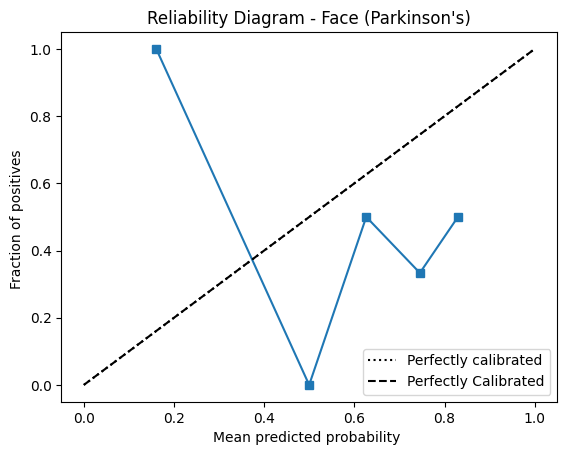

In [ ]:
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import numpy as np

print("\n--- FACE CALIBRATION ANALYSIS ---")

# 1. Convert our NumPy X_test array directly into a PyTorch Tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
face_labels = np.array(y_test).astype(int)

# 2. Get predictions directly from the model
model.eval()
with torch.no_grad():
    out = model(X_test_tensor)

    # Handles both 1-output (Sigmoid) and 2-output (Softmax) architectures safely
    if len(out.shape) > 1 and out.shape[1] > 1:
        face_probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
    else:
        face_probs = torch.sigmoid(out).squeeze().cpu().numpy()

# 3. Calculate Brier Score
brier = brier_score_loss(face_labels, face_probs)
print(f"Brier Score (Face): {brier:.4f} (Closer to 0.0 is better)")

# 4. Plot the Calibration Curve
prob_true, prob_pred = calibration_curve(face_labels, face_probs, n_bins=10)
disp = CalibrationDisplay(prob_true, prob_pred, face_labels)

plt.figure(figsize=(8, 6))
disp.plot()
plt.title("Reliability Diagram - Face (Parkinson's)")
plt.plot([0, 1], [0, 1], 'k--', label="Perfectly Calibrated")
plt.legend()
plt.savefig("calibration_face.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import torch
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

print("\n=======================================================")
print(" 1. FACE: BOOTSTRAPPED CONFIDENCE INTERVALS (95%)")
print("=======================================================")
# Re-evaluate to get predictions
model.eval()
with torch.no_grad():
    out = model(X_test_tensor)
    if len(out.shape) > 1 and out.shape[1] > 1:
        test_preds = out.argmax(1).cpu().numpy()
    else:
        test_preds = (torch.sigmoid(out).squeeze() > 0.5).int().cpu().numpy()

bootstrapped_scores = []
for i in range(1000):
    indices = resample(np.arange(len(test_preds)), replace=True)
    bootstrapped_scores.append(accuracy_score(face_labels[indices], test_preds[indices]))

lower_ci = np.percentile(bootstrapped_scores, 2.5)
upper_ci = np.percentile(bootstrapped_scores, 97.5)
print(f"✅ Accuracy: {np.mean(bootstrapped_scores)*100:.1f}% (95% CI: [{lower_ci*100:.1f}%, {upper_ci*100:.1f}%])")

print("\n=======================================================")
print(" 2. FACE: ROBUSTNESS TO NOISE (POOR WEBCAM TRACKING)")
print("=======================================================")
# Add random jitter to the 13 facial landmarks
noise_tensor = torch.randn_like(X_test_tensor) * 0.15 # 15% noise
X_test_noisy = X_test_tensor + noise_tensor

with torch.no_grad():
    out_noisy = model(X_test_noisy)
    if len(out.shape) > 1 and out.shape[1] > 1:
        noisy_preds = out_noisy.argmax(1).cpu().numpy()
    else:
        noisy_preds = (torch.sigmoid(out_noisy).squeeze() > 0.5).int().cpu().numpy()

print(f"✅ Noisy Tracking Accuracy: {accuracy_score(face_labels, noisy_preds)*100:.1f}%")

print("\n=======================================================")
print(" 3. FACE: FEATURE ABLATION (MASKING LOWER FACE)")
print("=======================================================")
# Zero out the last 5 features (simulating if we couldn't track the mouth/jaw)
X_test_ablated = X_test_tensor.clone()
X_test_ablated[:, -5:] = 0.0

with torch.no_grad():
    out_ablated = model(X_test_ablated)
    if len(out.shape) > 1 and out.shape[1] > 1:
        ablated_preds = out_ablated.argmax(1).cpu().numpy()
    else:
        ablated_preds = (torch.sigmoid(out_ablated).squeeze() > 0.5).int().cpu().numpy()

print(f"✅ Ablated Accuracy (Eyes Only / No Jaw): {accuracy_score(face_labels, ablated_preds)*100:.1f}%")


 1. FACE: BOOTSTRAPPED CONFIDENCE INTERVALS (95%)
✅ Accuracy: 44.6% (95% CI: [11.1%, 77.8%])

 2. FACE: ROBUSTNESS TO NOISE (POOR WEBCAM TRACKING)
✅ Noisy Tracking Accuracy: 33.3%

 3. FACE: FEATURE ABLATION (MASKING LOWER FACE)
✅ Ablated Accuracy (Eyes Only / No Jaw): 33.3%
